[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allison-diebol/open-iris/blob/main/colab/EvaluationSuiteDemo.ipynb)

# Evaluation Suite Demo

This notebook demonstrates how to use the **easy-to-use evaluation functions** for the open-iris pipeline. These helper functions abstract away the complexity of the full pipeline and allow for quick dataset experimentation and evaluation.

### Import Libraries

We begin by importing standard Python libraries for file handling and randomness, along with the **evaluation utilities** from the open-iris package.

The key functions used in this notebook are:

- `evaluate_dataset`: Runs the full pipeline (template creation, matching, scoring)
- `evaluation_report`: Prints a summary of performance metrics
- `plot_roc`: Visualizes the ROC curve
- `plot_far_frr`: Shows FAR vs FRR tradeoff
- `plot_score_distributions`: Displays genuine vs impostor score distributions

These functions are designed to simplify the evaluation process into just a few lines of code.

In [17]:
import sys
import os
import random
import shutil
from pathlib import Path

from iris.evaluation.evaluation_metrics import evaluate_dataset, evaluation_report, plot_roc, plot_far_frr, plot_score_distributions

### Prepare a Sample Dataset

The full dataset can be quite large, so we randomly sample a subset of images to make experimentation faster.

Steps performed here:
- Traverse the dataset directory
- Collect all available iris images
- Randomly select a subset (e.g., 500 images)
- Copy them into a temporary folder (`./sample_imgs`)

This sampled dataset will be used for evaluation in the next steps. Replace `src_root` with your folder of iris images.

In [11]:
src_root = Path("data-folder")

# Temp folder to hold sampled images
dst_root = Path("./sample_imgs")
dst_root.mkdir(exist_ok=True)

all_images = []
for subject_dir in src_root.iterdir():
    if not subject_dir.is_dir():
        continue
    for eye in ["L", "R"]:
        eye_dir = subject_dir / eye
        if eye_dir.exists():
            for img in eye_dir.glob("*.jpg"):
                all_images.append((subject_dir.name, eye, img))

print(f"Total images found: {len(all_images)}")

left_images = [x for x in all_images if x[1] == "L"]
sampled = random.sample(left_images, 500)

for i, (subject, eye, img_path) in enumerate(sampled):
    new_name = f"{subject}_{eye}_{i:04d}.jpg"
    shutil.copy(img_path, dst_root / new_name)

print(f"Copied {len(sampled)} images to {dst_root}")

Total images found: 20000
Copied 500 images to sample_imgs


The output confirms:
- Total number of images found in the dataset
- Number of images copied into the sample folder

This ensures we are working with a manageable subset while preserving dataset diversity.

### Run the Evaluation Pipeline

We now run the full evaluation pipeline using a single function call:

```python
result = evaluate_dataset(...)
```
It internally processes each image to generate a biometric template, generates genuine and imposter pairs, and computes the similarity scores.

In [12]:
result = evaluate_dataset(
    "./sample_imgs",
    eye_side="left",
    verbose=True
)

evaluation_report(result);


Loading templates from: ./sample_imgs
[40.0%] Processed 200/500 → OK: 180, SKIP: 20
[60.0%] Processed 300/500 → OK: 272, SKIP: 28
[80.0%] Processed 400/500 → OK: 371, SKIP: 29
[100.0%] Processed 500/500 → OK: 465, SKIP: 35

Finished processing 500 images
OK: 465
SKIP: 35

Building pairs from 465 templates …
    Genuine pairs : 104
    Impostor pairs: 107776

Computing match scores …
════════════════════════════════════════════════════
  open-iris  |  Evaluation Report
════════════════════════════════════════════════════
  Genuine comparisons : 104
  Impostor comparisons: 107,776

  EER                 : 8.634 %
  EER threshold       : 0.45430
  AUC (ROC)           : 0.93131

  Operating points:
    FAR=0.1%  →  FRR=13.46%  (threshold=0.4155)
    FAR=1.0%  →  FRR=10.58%  (threshold=0.4335)
    FAR=10.0%  →  FRR=8.65%  (threshold=0.4562)
════════════════════════════════════════════════════


During execution, the pipeline provides progress updates:

- **OK**: Successfully processed images  
- **SKIP**: Images that failed processing  
- **Progress %**: Indicates how much of the dataset has been processed  

After processing:
- Templates are used to generate genuine and impostor pairs
- Match scores are computed for all comparisons

This gives insight into both **data quality** and **pipeline robustness**.

### Evaluation Report

We now summarize the performance using:

```python
evaluation_report(result)
```
This report includes:
- Genuines comparisons
- Imposter comparisons
- Equal Error Rate (EER)
- Area Under the Curve (AUC)
- Performance at specific False Accept Rate (FAR) thresholds

### Key Takeaways

- A lower **EER** indicates better performance  
- A higher **AUC** (closer to 1) indicates stronger separation between classes  
- The imbalance between impostor and genuine pairs is expected due to combinatorics

This report provides a quick, high-level understanding of system effectiveness.

### ROC Curve

The ROC (Receiver Operating Characteristic) curve visualizes the tradeoff between:

- **False Accept Rate (FAR)**
- **True Accept Rate (TAR)**

A curve closer to the top-left corner indicates better performance.

This plot helps us understand how well the system separates genuine and impostor matches across thresholds.

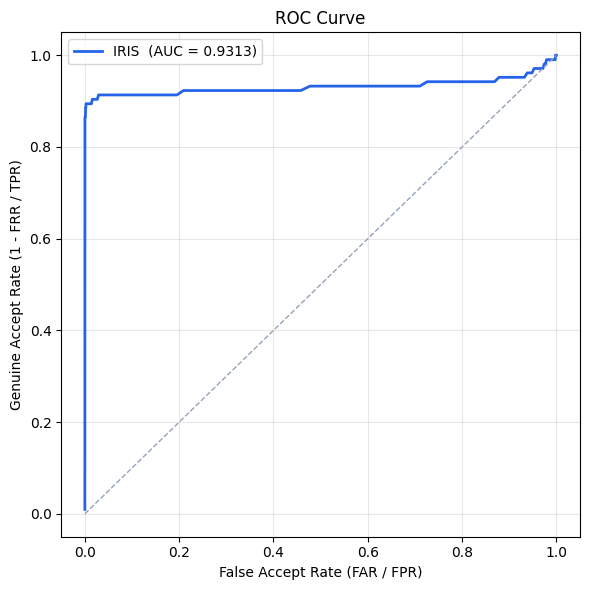

In [15]:
plot_roc(result);

### FAR vs FRR Curve

This plot shows the relationship between:

- **FAR (False Accept Rate)**
- **FRR (False Reject Rate)**

The intersection point corresponds to the **Equal Error Rate (EER)**.

This visualization is especially useful for selecting an appropriate decision threshold depending on application requirements.

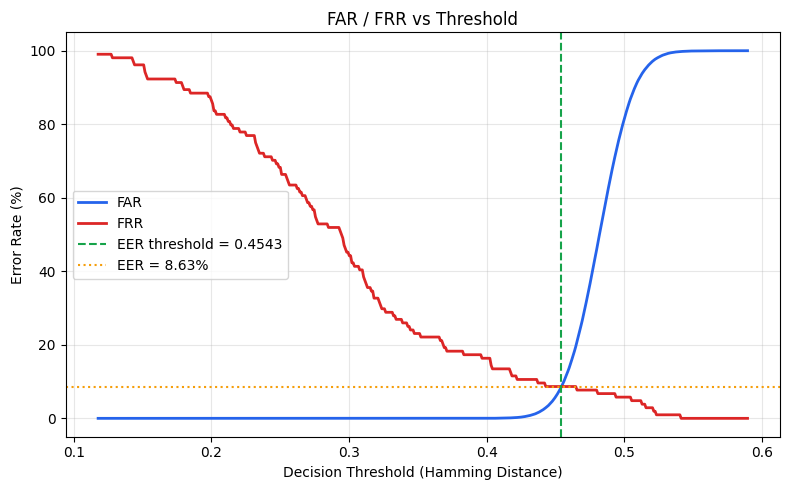

In [16]:
plot_far_frr(result);

### Score Distributions

This plot shows the distribution of similarity scores for:

- Genuine pairs (same subject)
- Impostor pairs (different subjects)

Ideal behavior:
- Genuine scores are tightly grouped and high
- Impostor scores are lower and well separated

Overlap between the two distributions indicates potential classification errors.

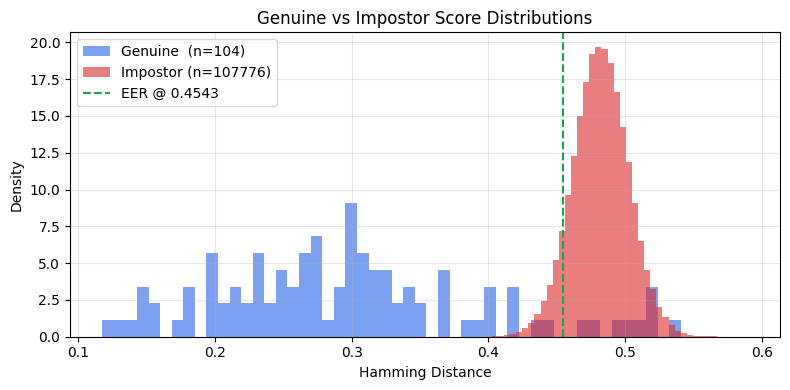

In [18]:
plot_score_distributions(result);

In [19]:
evaluation_report(result);

════════════════════════════════════════════════════
  open-iris  |  Evaluation Report
════════════════════════════════════════════════════
  Genuine comparisons : 104
  Impostor comparisons: 107,776

  EER                 : 8.634 %
  EER threshold       : 0.45430
  AUC (ROC)           : 0.93131

  Operating points:
    FAR=0.1%  →  FRR=13.46%  (threshold=0.4155)
    FAR=1.0%  →  FRR=10.58%  (threshold=0.4335)
    FAR=10.0%  →  FRR=8.65%  (threshold=0.4562)
════════════════════════════════════════════════════


## Summary

In this notebook, we demonstrated how to:

- Quickly evaluate an iris dataset using high-level helper functions
- Generate meaningful biometric metrics with minimal code
- Visualize system performance through standard plots

These utilities make it easy to experiment with different datasets, preprocessing choices, and evaluation settings without needing to manually implement the full pipeline.